In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.pipeline import Pipeline as IMB_Pipeline


In [4]:
data = pd.read_csv("clean_data.csv")
data['Transaction_Time'] = pd.to_datetime(data['Transaction_Time'], format='%H:%M:%S')
data['Transaction_Hour'] = data['Transaction_Time'].dt.hour
data['Transaction_Date'] = pd.to_datetime(data['Transaction_Date'], format='%Y-%m-%d')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49866 entries, 0 to 49865
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Unnamed: 0                             49866 non-null  int64         
 1   Transaction_ID                         49866 non-null  float64       
 2   Customer_ID                            49866 non-null  float64       
 3   Transaction_Amount (in Million)        49866 non-null  float64       
 4   Transaction_Time                       49866 non-null  datetime64[us]
 5   Transaction_Date                       49866 non-null  datetime64[us]
 6   Transaction_Type                       49866 non-null  str           
 7   Merchant_Category                      49866 non-null  str           
 8   Transaction_Location                   49866 non-null  str           
 9   Customer_Home_Location                 49866 non-null  str           
 1

In [5]:
data.head()

,Unnamed: 0,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Is_Fraud,Transaction_Hour
0,0,431438.0,24239.0,6.0,1900-01-01 10:54:00,2025-03-08,POS,ATM,Singapore,Lahore,...,17.0,2.0,4.0,1,1,0.0,0,1.0,0,10
1,1,902451.0,77250.0,9.0,1900-01-01 19:23:00,2025-01-17,ATM,ATM,Singapore,Lahore,...,9.0,5.0,8.0,1,1,1.0,0,1.0,0,19
2,2,223410.0,34294.0,3.0,1900-01-01 10:20:00,2025-04-30,POS,Electronics,Faisalabad,Faisalabad,...,18.0,5.0,8.0,1,0,0.0,1,1.0,0,10
3,3,145626.0,92041.0,1.0,1900-01-01 14:11:00,2025-02-21,Online,Grocery,London,Karachi,...,18.0,5.0,1.0,0,1,2.0,1,1.0,0,14
4,4,414637.0,71578.0,1.0,1900-01-01 04:12:00,2025-04-11,Online,Electronics,Singapore,Islamabad,...,18.0,4.0,3.0,0,1,1.0,0,1.0,0,4


## Data Cleaning & Preparation

In [6]:
binary_features = ['Is_New_Merchant', 'Is_International_Transaction', 'Unusual_Time_Transaction']
categorical_features = ['Card_Type', 'Merchant_Category', 'Transaction_Type']
numeric_features = [
    'Transaction_Amount (in Million)', 'Previous_Fraud_Count', 'Account_Balance (in Million)',
    'Distance_From_Home', 'Daily_Transaction_Count', 'Weekly_Transaction_Count',
    'Avg_Transaction_Amount (in Million)', 'Max_Transaction_Last_24h (in Million)', 'Failed_Transaction_Count',
    'Transaction_Hour'
]

keep_cols = binary_features + categorical_features + numeric_features + ['Is_Fraud']

data_cleaned = data[keep_cols].copy()

data_cleaned.head()


,Is_New_Merchant,Is_International_Transaction,Unusual_Time_Transaction,Card_Type,Merchant_Category,Transaction_Type,Transaction_Amount (in Million),Previous_Fraud_Count,Account_Balance (in Million),Distance_From_Home,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Transaction_Hour,Is_Fraud
0,1,1,0,Credit,ATM,POS,6.0,1.0,30.0,466.0,4.0,17.0,2.0,4.0,0.0,10,0
1,1,1,0,Credit,ATM,ATM,9.0,1.0,4.0,215.0,4.0,9.0,5.0,8.0,1.0,19,0
2,0,1,1,Debit,Electronics,POS,3.0,1.0,38.0,216.0,5.0,18.0,5.0,8.0,0.0,10,0
3,1,0,1,Debit,Grocery,Online,1.0,1.0,22.0,408.0,6.0,18.0,5.0,1.0,2.0,14,0
4,1,0,0,Debit,Electronics,Online,1.0,1.0,10.0,209.0,3.0,18.0,4.0,3.0,1.0,4,0


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('bin', OneHotEncoder(drop='if_binary'), binary_features)
    ])

clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('classifier', DecisionTreeClassifier(max_depth=4))])

In [8]:
X = data_cleaned.drop(columns=['Is_Fraud'])
y = data_cleaned['Is_Fraud']

target_names = ['No Fraud', "Fraud"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nTarget names:", target_names)
print("\nClass counts:")
print(y.value_counts().sort_index())

Feature matrix shape: (49866, 16)
Target vector shape: (49866,)

Target names: ['No Fraud', 'Fraud']

Class counts:
Is_Fraud
0    47449
1     2417
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (37399, 16)
Test set shape: (12467, 16)


## Helper Functions

In [157]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results = {
        "model": model_name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    }

    if hasattr(model, "predict_proba"):
        test_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, test_proba)
        roc_auc = auc(fpr, tpr)
        results["roc_auc"] = roc_auc
    else:
        results["roc_auc"] = np.nan

    return model, results


def plot_roc_curves(curves_dict):
    fig, ax = plt.subplots()
    for name, (fpr, tpr, roc_auc) in curves_dict.items():
        ax.plot(fpr, tpr, label=f"{name}  AUC={roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curves on the test set")
    ax.legend()
    plt.show()

def pr_curve(y_test, X_test, pipe):
    y_scores = pipe.predict_proba(X_test)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_test, y_scores)
    plt.figure(figsize=(6, 4))
    plt.plot(rec, prec, label=f'PR curve (AP = {ap:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision–Recall curve for Fraud class')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_decision_boundary(model, X, y, title, feature_names):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots()
    ax.contourf(xx, yy, Z, alpha=0.25)

    for cls, label in zip([0, 1], ["No Fraud", "Fraud"]):
        mask = y == cls
        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            label=label,
            alpha=0.8
        )

    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    ax.legend()
    plt.show()

## Base Model

In [11]:
clf.fit(X_train, y_train)
clf, tree_results = evaluate_classifier(clf, X_train, X_test, y_train, y_test, "Decision Tree")
pd.DataFrame([tree_results])

,model,train_accuracy,test_accuracy,roc_auc
0,Decision Tree,0.951523,0.951552,0.601789


              precision    recall  f1-score   support

    No Fraud       0.95      1.00      0.98     11863
       Fraud       0.00      0.00      0.00       604

    accuracy                           0.95     12467
   macro avg       0.48      0.50      0.49     12467
weighted avg       0.91      0.95      0.93     12467



/Users/amiebinan/Desktop/WPI/Y25-26/D26/DATA SCIENCE/Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amiebinan/Desktop/WPI/Y25-26/D26/DATA SCIENCE/Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/amiebinan/Desktop/WPI/Y25-26/D26/DATA SCIENCE/Project/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Us

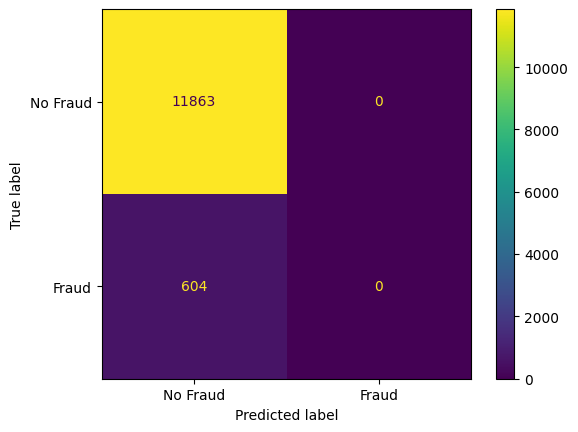

In [12]:
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Fraud", "Fraud"]).plot()

print(classification_report(y_test, y_pred, target_names=target_names))

## Model Tweaking

### Behavioral Inputs

In [13]:
behavioral_data = data.copy()

# Timing of Transactions
behavioral_data = behavioral_data.sort_values(['Customer_ID', 'Transaction_Date', 'Transaction_Time'])
behavioral_data['Time_Diff'] = behavioral_data.groupby('Customer_ID')['Transaction_Time'].diff()
behavioral_data['Min_Since_Last_Tx'] = behavioral_data['Time_Diff'].dt.total_seconds() / 60
behavioral_data['Min_Since_Last_Tx'] = behavioral_data['Min_Since_Last_Tx'].fillna(999)
behavioral_data['Transactions_Today'] = behavioral_data.groupby(['Customer_ID', 'Transaction_Date']).cumcount() + 1

# Spending Trends
behavioral_data['Customer_Hist_Avg'] = (behavioral_data.groupby('Customer_ID')['Transaction_Amount (in Million)']
                                        .transform(lambda x: x.expanding().mean()))
behavioral_data['Spend_to_Avg_Ratio'] = (behavioral_data['Transaction_Amount (in Million)']
                                         / (behavioral_data['Customer_Hist_Avg'] + 1e-9))
behavioral_data['Customer_Hist_Max'] = (behavioral_data.groupby('Customer_ID')['Transaction_Amount (in Million)']
                                        .transform(lambda x: x.expanding().max()))
behavioral_data['Is_New_Spend_Record'] = (behavioral_data['Transaction_Amount (in Million)']
                                          >= behavioral_data['Customer_Hist_Max']).astype(int)

In [14]:
behavioral_data.head(100)
# behavioral_data.to_csv('behavioral_data.csv')
# behavioral_data.columns

,Unnamed: 0,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Previous_Fraud_Count,Is_Fraud,Transaction_Hour,Time_Diff,Min_Since_Last_Tx,Transactions_Today,Customer_Hist_Avg,Spend_to_Avg_Ratio,Customer_Hist_Max,Is_New_Spend_Record
16861,16921,241579.0,10005.0,9.0,1900-01-01 15:11:00,2025-03-09,ATM,Electronics,Multan,Lahore,...,0.0,0,15,NaT,999.0,1,9.000000,1.000000,9.0,1
12912,12961,516068.0,10009.0,7.0,1900-01-01 20:52:00,2025-01-15,POS,Grocery,Multan,Karachi,...,0.0,0,20,NaT,999.0,1,7.000000,1.000000,7.0,1
23195,23271,402225.0,10009.0,4.0,1900-01-01 22:58:00,2025-01-18,Online,Restaurant,Bangkok,Multan,...,1.0,0,22,0 days 02:06:00,126.0,1,5.500000,0.727273,7.0,0
12961,13011,529848.0,10009.0,4.0,1900-01-01 06:25:00,2025-02-07,Online,Fuel,London,Lahore,...,1.0,0,6,-1 days +07:27:00,-993.0,1,5.000000,0.800000,7.0,0
16271,16329,531951.0,10013.0,9.0,1900-01-01 11:14:00,2025-03-23,POS,ATM,Karachi,Multan,...,1.0,0,11,NaT,999.0,1,9.000000,1.000000,9.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2420,2430,428649.0,10191.0,9.0,1900-01-01 17:49:00,2025-03-13,ATM,Fuel,Bangkok,Lahore,...,0.0,0,17,0 days 14:43:00,883.0,1,4.666667,1.928571,9.0,1
48186,48316,756431.0,10192.0,9.0,1900-01-01 19:06:00,2025-02-27,ATM,Restaurant,Lahore,Karachi,...,1.0,0,19,NaT,999.0,1,9.000000,1.000000,9.0,1
49365,49497,370129.0,10193.0,4.0,1900-01-01 19:32:00,2025-03-24,ATM,Restaurant,Dubai,Karachi,...,1.0,0,19,NaT,999.0,1,4.000000,1.000000,4.0,1
41323,41446,885061.0,10195.0,6.0,1900-01-01 19:16:00,2025-03-15,ATM,Restaurant,Faisalabad,Lahore,...,0.0,0,19,NaT,999.0,1,6.000000,1.000000,6.0,1


In [15]:
new_binary_features = ['Is_New_Merchant', 'Is_International_Transaction', 'Unusual_Time_Transaction', 'Is_New_Spend_Record']
new_categorical_features = ['Card_Type', 'Merchant_Category', 'Transaction_Type']
new_numeric_features = [
    'Transaction_Amount (in Million)', 'Previous_Fraud_Count',
    'Distance_From_Home', 'Max_Transaction_Last_24h (in Million)', 'Failed_Transaction_Count',
    'Transaction_Hour', 'Spend_to_Avg_Ratio', 'Transactions_Today', 'Min_Since_Last_Tx', 'Customer_Hist_Avg',
]

new_keep_cols = new_binary_features + new_categorical_features + new_numeric_features + ['Is_Fraud', 'Customer_ID']

new_data_cleaned = behavioral_data[new_keep_cols].copy()

new_data_cleaned.head()

,Is_New_Merchant,Is_International_Transaction,Unusual_Time_Transaction,Is_New_Spend_Record,Card_Type,Merchant_Category,Transaction_Type,Transaction_Amount (in Million),Previous_Fraud_Count,Distance_From_Home,Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Transaction_Hour,Spend_to_Avg_Ratio,Transactions_Today,Min_Since_Last_Tx,Customer_Hist_Avg,Is_Fraud,Customer_ID
16861,0,0,0,1,Credit,Electronics,ATM,9.0,0.0,562.0,9.0,2.0,15,1.000000,1,999.0,9.0,0,10005.0
12912,0,1,0,1,Debit,Grocery,POS,7.0,0.0,364.0,3.0,2.0,20,1.000000,1,999.0,7.0,0,10009.0
23195,0,0,1,0,Debit,Restaurant,Online,4.0,1.0,549.0,7.0,0.0,22,0.727273,1,126.0,5.5,0,10009.0
12961,0,0,0,0,Debit,Fuel,Online,4.0,1.0,462.0,5.0,1.0,6,0.800000,1,-993.0,5.0,0,10009.0
16271,1,1,0,1,Credit,ATM,POS,9.0,1.0,62.0,6.0,1.0,11,1.000000,1,999.0,9.0,0,10013.0


In [154]:
new_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), new_numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), new_categorical_features),
        ('bin', OneHotEncoder(drop='if_binary'), new_binary_features)
    ]
)

# update classifier step in the pipeline
new_clf = Pipeline(steps=[
    ('preprocessor', new_preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=6,
        class_weight={0: 1.0, 1: 15.0},
        min_samples_leaf=5,
        random_state=42
    ))
])

In [17]:
new_X = new_data_cleaned.drop(columns=['Is_Fraud'])
new_y = new_data_cleaned['Is_Fraud']

target_names = ['No Fraud', "Fraud"]

print("Feature matrix shape:", new_X.shape)
print("Target vector shape:", new_y.shape)
print("\nTarget names:", target_names)
print("\nClass counts:")
print(new_y.value_counts().sort_index())

Feature matrix shape: (49866, 18)
Target vector shape: (49866,)

Target names: ['No Fraud', 'Fraud']

Class counts:
Is_Fraud
0    47449
1     2417
Name: count, dtype: int64


In [155]:
# the same customer should consistently appear in training or test data, not both
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

# split group by customer
train_idx, test_idx = next(gss.split(new_X, new_y, groups=behavioral_data['Customer_ID']))
X_train_grouped = new_X.iloc[train_idx]
y_train_grouped = new_y.iloc[train_idx]
X_test_grouped = new_X.iloc[test_idx]
y_test_grouped = new_y.iloc[test_idx]

# don't need customer id
X_train_final = X_train_grouped.drop(columns=['Customer_ID'])
X_test_final = X_test_grouped.drop(columns=['Customer_ID'])

print("Training set shape:", X_train_final.shape)
print("Test set shape:", X_test_final.shape)

Training set shape: (37375, 17)
Test set shape: (12491, 17)


In [19]:
from collections import Counter

Counter(y_train_grouped)

Counter({0: 35582, 1: 1793})

In [156]:
new_clf.fit(X_train_final, y_train_grouped)
new_clf, new_tree_results = evaluate_classifier(
    new_clf, X_train_final, X_test_final, y_train_grouped, y_test_grouped,
    "Decision Tree"
)
pd.DataFrame([new_tree_results])
# pr_curve(y_test_grouped, X_test_final, new_clf)

,model,train_accuracy,test_accuracy,roc_auc
0,Decision Tree,0.710662,0.699704,0.590774


              precision    recall  f1-score   support

    No Fraud       0.96      0.72      0.82     11867
       Fraud       0.07      0.41      0.12       624

    accuracy                           0.70     12491
   macro avg       0.51      0.56      0.47     12491
weighted avg       0.91      0.70      0.78     12491



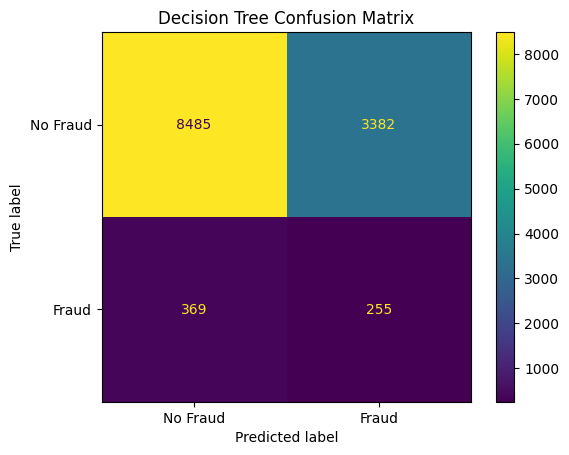

In [165]:
new_y_pred = new_clf.predict(X_test_final)

new_cm = confusion_matrix(y_test_grouped, new_y_pred)
disp = ConfusionMatrixDisplay(new_cm, display_labels=["No Fraud", "Fraud"]).plot()
disp.ax_.set_title("Decision Tree Confusion Matrix") # set title

print(classification_report(y_test_grouped, new_y_pred, target_names=target_names))

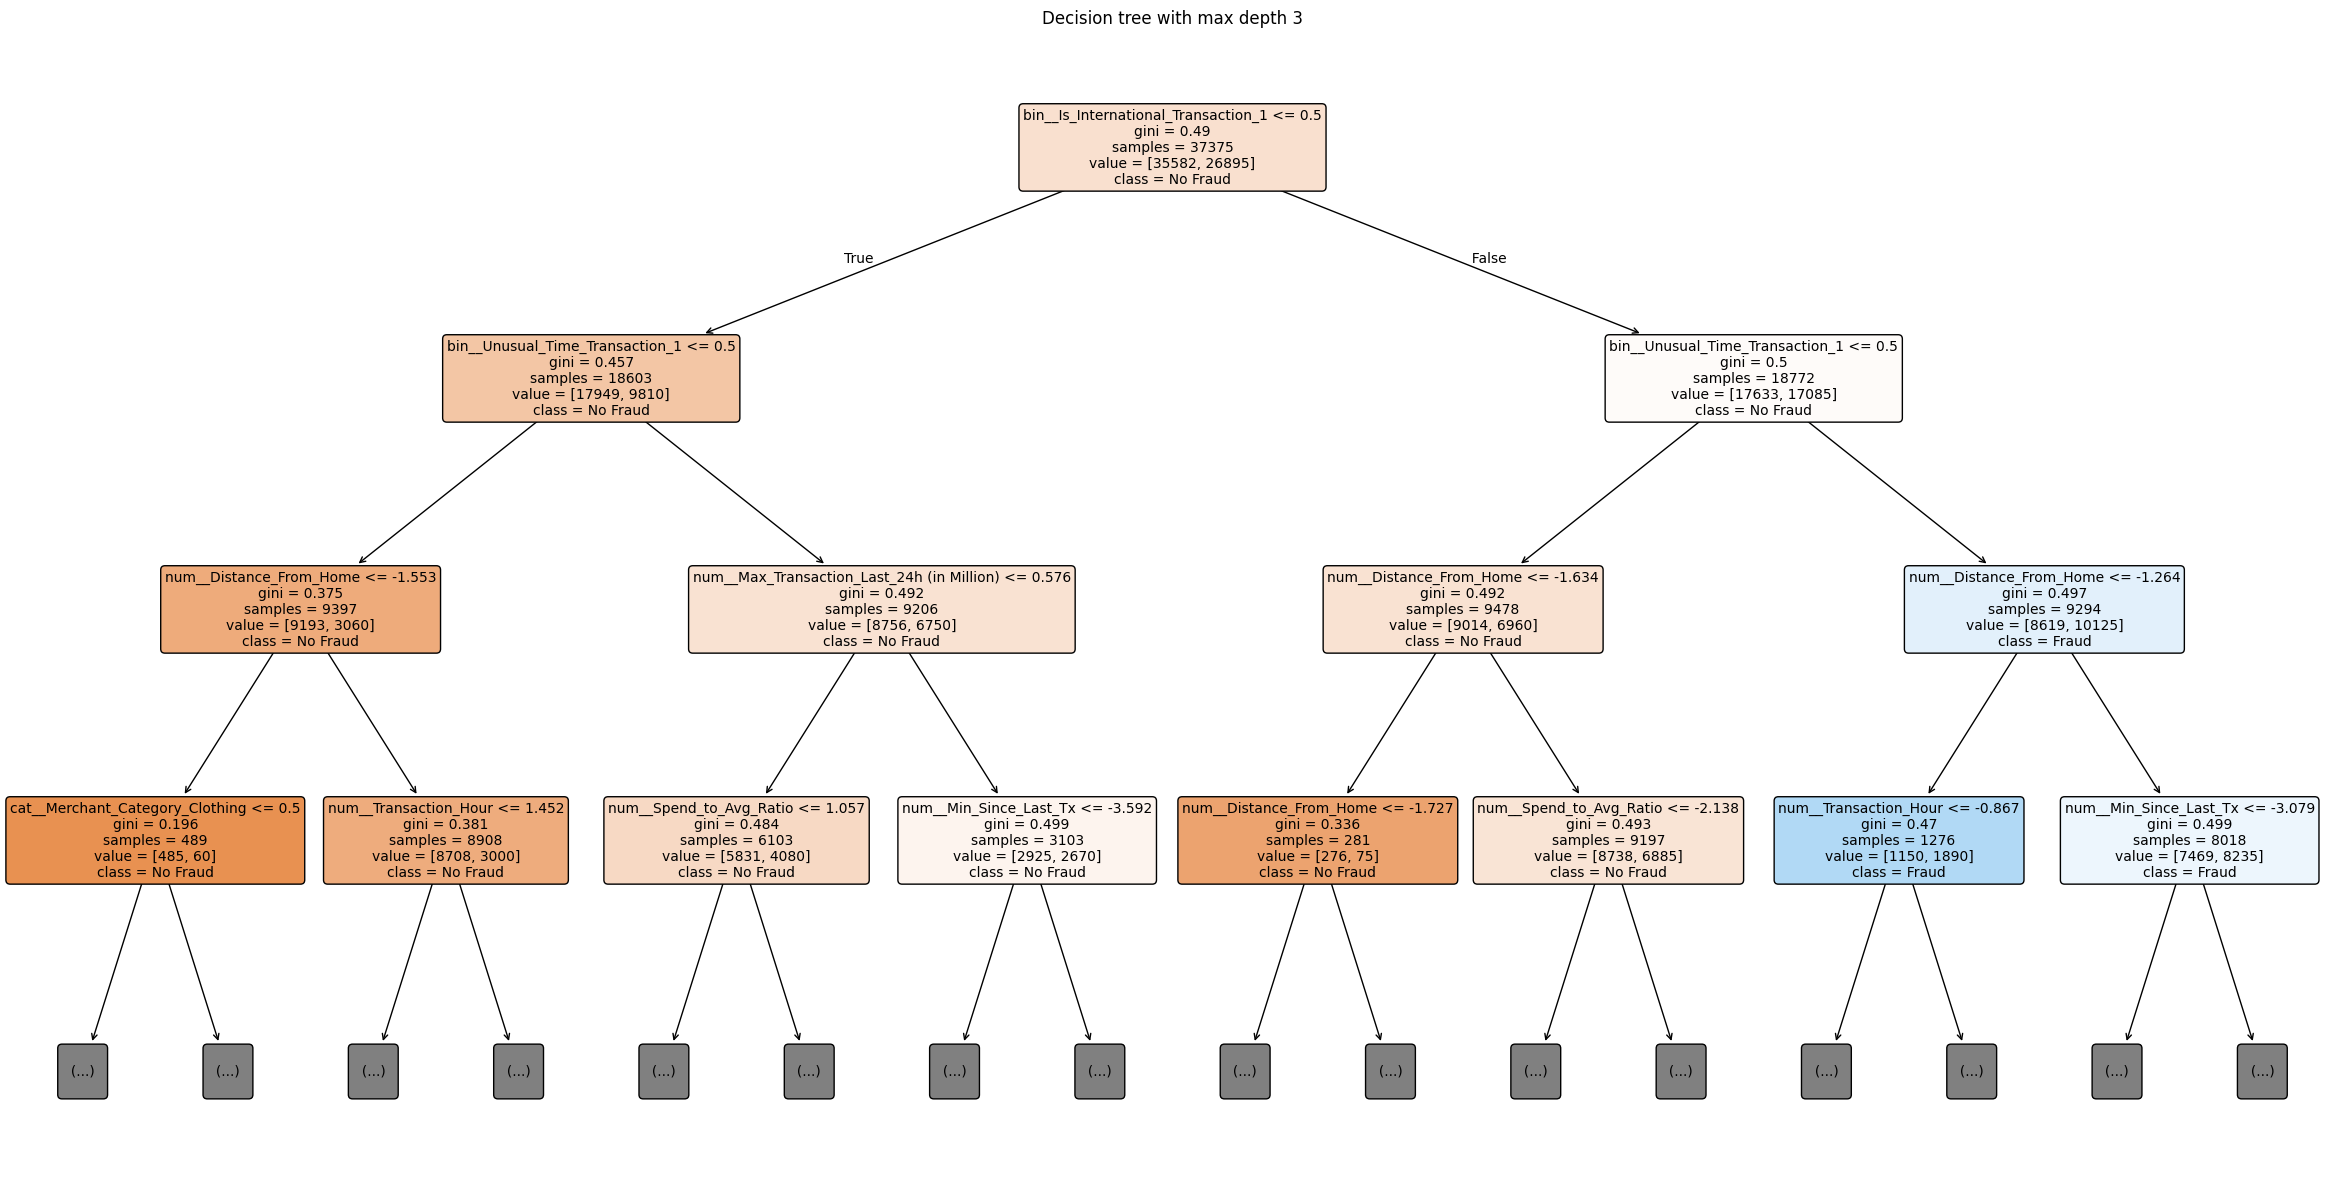

In [166]:
tree = new_clf.named_steps['classifier']
feature_names = new_clf.named_steps['preprocessor'].get_feature_names_out()

fig, ax = plt.subplots(figsize=(30, 15))
plot_tree(
    tree,
    max_depth=3,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title("Decision tree with max depth 3")
plt.show()

In [131]:
decision_tree = new_clf.named_steps['classifier']
feature_names = new_clf.named_steps['preprocessor'].get_feature_names_out()

importances = pd.Series(decision_tree.feature_importances_, index=feature_names)
importances_sorted = importances.sort_values(ascending=False)

print(importances_sorted.head(10))

bin__Unusual_Time_Transaction_1               0.269755
bin__Is_International_Transaction_1           0.242725
num__Distance_From_Home                       0.154887
num__Max_Transaction_Last_24h (in Million)    0.060447
num__Transaction_Hour                         0.060104
num__Min_Since_Last_Tx                        0.059027
num__Spend_to_Avg_Ratio                       0.048557
num__Customer_Hist_Avg                        0.039874
cat__Merchant_Category_Clothing               0.021809
num__Failed_Transaction_Count                 0.014751
dtype: float64


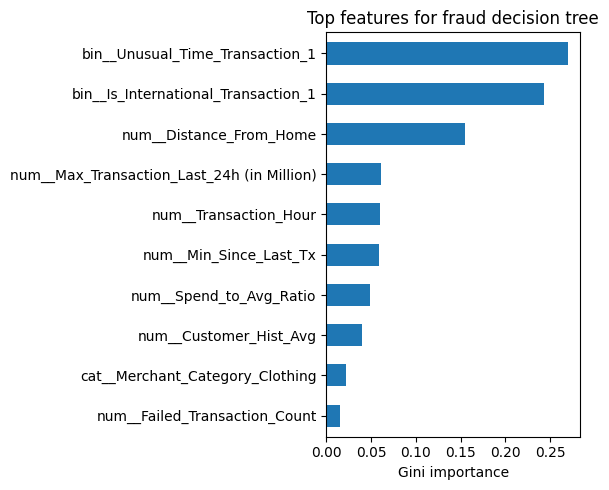

In [134]:
importances_sorted.head(10).plot(kind="barh", figsize=(6, 5), width=0.55)
plt.gca().invert_yaxis()
plt.xlabel("Gini importance")
plt.title("Top features for fraud decision tree")
plt.tight_layout()
plt.show()

## Over/Under Sampling

In [64]:
sampling_clf = IMB_Pipeline(steps=[
    ('preprocessor', new_preprocessor),
    ('oversample', SMOTE(sampling_strategy=0.4, random_state=42)),  # Boost minority to 30% of majority
    ('undersample', RandomUnderSampler(sampling_strategy=0.6, random_state=42)), # Reduce majority further
    ('classifier', DecisionTreeClassifier(
        max_depth=10,
        class_weight={0: 1, 1: 5},
        random_state=42
    ))
])

sampling_clf.fit(X_train_final, y_train_grouped)

# Get PR curve on validation set
# y_scores = pipe.predict_proba(X_test_final)[:, 1]
# prec, rec, thresholds = precision_recall_curve(y_test_grouped, y_scores)
# ap = average_precision_score(y_test_grouped, y_scores)

,steps,"[('preprocessor', ...), ('oversample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for forma

In [65]:
sampling_y_pred = sampling_clf.predict(X_test_final)

sampling_clf, sampling_tree_results = evaluate_classifier(
    sampling_clf, X_train_final, X_test_final, y_train_grouped, y_test_grouped,
    "Decision Tree (with Resampling)"
)
pd.DataFrame([sampling_tree_results])

,model,train_accuracy,test_accuracy,roc_auc
0,Decision Tree (with Resampling),0.530729,0.502282,0.58736


              precision    recall  f1-score   support

    No Fraud       0.96      0.50      0.65     11867
       Fraud       0.06      0.63      0.11       624

    accuracy                           0.50     12491
   macro avg       0.51      0.56      0.38     12491
weighted avg       0.92      0.50      0.63     12491



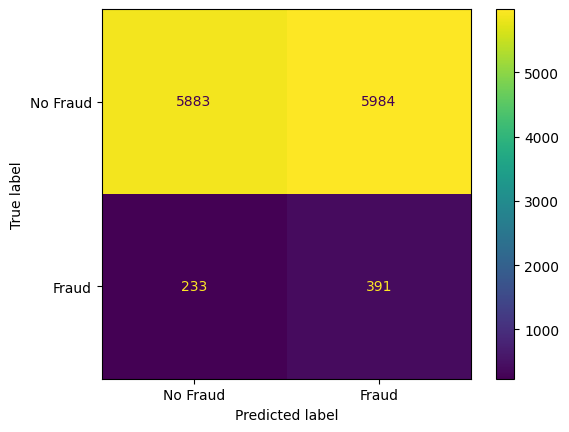

In [66]:
sampling_cm = confusion_matrix(y_test_grouped, sampling_y_pred)
ConfusionMatrixDisplay(sampling_cm, display_labels=["No Fraud", "Fraud"]).plot()

print(classification_report(y_test_grouped, sampling_y_pred, target_names=target_names))

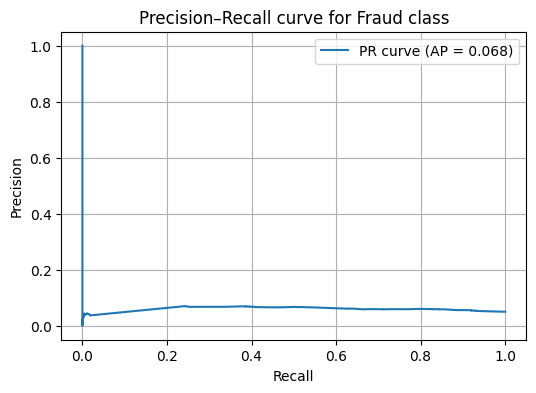

In [67]:
pr_curve(y_test_grouped, X_test_final, sampling_clf)

## Random Forest

In [94]:
rf_clf = IMB_Pipeline(steps=[
    ('preprocessor', new_preprocessor),
    ('oversample', SMOTE(sampling_strategy=0.5, random_state=42)),  # Boost minority to 30% of majority
    ('undersample', RandomUnderSampler(sampling_strategy=0.5, random_state=42)), # Reduce majority further
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=20,
        class_weight={0: 1, 1: 5},
        random_state=42
    ))
])

# Fit the model
rf_clf.fit(X_train_final, y_train_grouped)

# Evaluate
rf_clf, rf_results = evaluate_classifier(
    rf_clf, X_train_final, X_test_final, y_train_grouped, y_test_grouped,
    "Random Forest"
)
pd.DataFrame([rf_results])
# pr_curve(y_test_grouped, X_test_final, rf_clf)

,model,train_accuracy,test_accuracy,roc_auc
0,Random Forest,0.639278,0.613882,0.597155


              precision    recall  f1-score   support

    No Fraud       0.96      0.62      0.75     11867
       Fraud       0.07      0.51      0.12       624

    accuracy                           0.61     12491
   macro avg       0.51      0.56      0.43     12491
weighted avg       0.92      0.61      0.72     12491



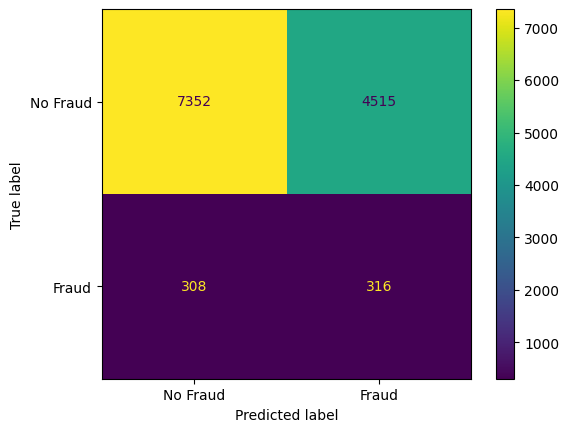

In [95]:
rf_y_pred = rf_clf.predict(X_test_final)

rf_cm = confusion_matrix(y_test_grouped, rf_y_pred)
ConfusionMatrixDisplay(rf_cm, display_labels=["No Fraud", "Fraud"]).plot()

print(classification_report(y_test_grouped, rf_y_pred, target_names=target_names))

In [84]:
from imblearn.ensemble import BalancedRandomForestClassifier

rf_clf = IMB_Pipeline(steps=[
    ('preprocessor', new_preprocessor),
    # REMOVE SMOTE and RandomUnderSampler here
    ('classifier', BalancedRandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        sampling_strategy='all', # Balanced bootstrap for every tree
        replacement=True,
        bootstrap=True,
        random_state=42,
        min_samples_leaf=50,
    ))
])

# Fit the model
rf_clf.fit(X_train_final, y_train_grouped)

# Evaluate
rf_clf, rf_results = evaluate_classifier(
    rf_clf, X_train_final, X_test_final, y_train_grouped, y_test_grouped,
    "Random Forest"
)
pd.DataFrame([rf_results])

,model,train_accuracy,test_accuracy,roc_auc
0,Random Forest,0.716709,0.661036,0.599819


              precision    recall  f1-score   support

    No Fraud       0.96      0.67      0.79     11867
       Fraud       0.06      0.43      0.11       624

    accuracy                           0.66     12491
   macro avg       0.51      0.55      0.45     12491
weighted avg       0.91      0.66      0.76     12491



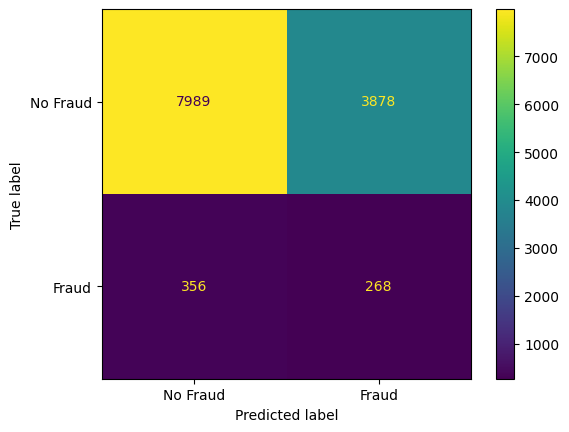

In [85]:
rf_y_pred = rf_clf.predict(X_test_final)

rf_cm = confusion_matrix(y_test_grouped, rf_y_pred)
ConfusionMatrixDisplay(rf_cm, display_labels=["No Fraud", "Fraud"]).plot()

print(classification_report(y_test_grouped, rf_y_pred, target_names=target_names))